In [4]:
import pandas as pd

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [6]:
df = pd.read_csv("/content/energy_features.csv")

In [7]:
df["time"] = pd.to_datetime(df["time"], utc=True)

In [8]:
df = df.sort_values("time").reset_index(drop=True)

In [9]:
print(df.shape)

(34859, 20)


In [10]:
print(df.head())

                       time     load  price  hour  dayofweek  month  \
0 2015-01-08 05:00:00+00:00  22551.0  44.81     5          3      1   
1 2015-01-08 06:00:00+00:00  22543.0  44.81     6          3      1   
2 2015-01-08 07:00:00+00:00  24042.0  46.85     7          3      1   
3 2015-01-08 08:00:00+00:00  25932.0  49.00     8          3      1   
4 2015-01-08 09:00:00+00:00  27664.0  54.36     9          3      1   

   is_weekend  hour_sin      hour_cos   dow_sin   dow_cos  load_lag_1  \
0           0  0.965926  2.588190e-01  0.433884 -0.900969     22361.0   
1           0  1.000000  6.123234e-17  0.433884 -0.900969     22551.0   
2           0  0.965926 -2.588190e-01  0.433884 -0.900969     22543.0   
3           0  0.866025 -5.000000e-01  0.433884 -0.900969     24042.0   
4           0  0.707107 -7.071068e-01  0.433884 -0.900969     25932.0   

   load_lag_24  load_lag_168  price_lag_1  price_lag_24  load_rollmean_24  \
0      26992.0       25385.0        44.68         59.13  

In [11]:
print(df.columns.tolist())

['time', 'load', 'price', 'hour', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'load_lag_1', 'load_lag_24', 'load_lag_168', 'price_lag_1', 'price_lag_24', 'load_rollmean_24', 'load_rollmean_168', 'price_rollmean_24', 'y_load_tplus1']


In [12]:
feature_cols = [
    "load",
    "price",
    "hour",
    "dayofweek",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "load_lag_1",
    "load_lag_24",
    "load_lag_168",
    "price_lag_1",
    "price_lag_24",
    "load_rollmean_24",
    "load_rollmean_168",
    "price_rollmean_24"
]

In [13]:
target_col = "y_load_tplus1"

In [14]:
X = df[feature_cols]
y = df[target_col]

In [15]:
split_index = int(len(df) * 0.8)

In [16]:
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [17]:
time_train = df["time"].iloc[:split_index]
time_test = df["time"].iloc[split_index:]

In [18]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (27887, 18)
Test set shape: (6972, 18)


In [19]:
print("Train start:", time_train.min(), "Train end:", time_train.max())
print("Test start:", time_test.min(), "Test end:", time_test.max())

Train start: 2015-01-08 05:00:00+00:00 Train end: 2018-03-16 07:00:00+00:00
Test start: 2018-03-16 08:00:00+00:00 Test end: 2018-12-31 21:00:00+00:00


**first baseline model: lag-1 baseline**

In [20]:
y_pred_baseline_lag1 = X_test["load"].copy()

In [21]:
y_pred_baseline_lag1 = X_test["load"].copy()

In [25]:
mae_lag1 = mean_absolute_error(y_test, y_pred_baseline_lag1)

In [26]:
rmse_lag1 = mean_squared_error(y_test, y_pred_baseline_lag1) ** 0.5

In [27]:
mape_lag1 = mean_absolute_percentage_error(y_test, y_pred_baseline_lag1)

In [28]:
print("Lag-1 Baseline MAE:", mae_lag1)
print("Lag-1 Baseline RMSE:", rmse_lag1)
print("Lag-1 Baseline MAPE:", mape_lag1)

Lag-1 Baseline MAE: 1048.653471026965
Lag-1 Baseline RMSE: 1396.3465013820794
Lag-1 Baseline MAPE: 0.03714434407261859


**second baseline: lag-24 baseline**

In [29]:
y_pred_baseline_lag24 = X_test["load_lag_24"].copy()

In [30]:
y_pred_baseline_lag24 = X_test["load_lag_24"].copy()

In [33]:
mae_lag24 = mean_absolute_error(y_test, y_pred_baseline_lag24)

In [31]:
rmse_lag24 = mean_squared_error(y_test, y_pred_baseline_lag24) ** 0.5

In [32]:
mape_lag24 = mean_absolute_percentage_error(y_test, y_pred_baseline_lag24)

In [34]:
print("Lag-24 Baseline MAE:", mae_lag24)
print("Lag-24 Baseline RMSE:", rmse_lag24)
print("Lag-24 Baseline MAPE:", mape_lag24)

Lag-24 Baseline MAE: 2817.4024670109006
Lag-24 Baseline RMSE: 3754.026213905188
Lag-24 Baseline MAPE: 0.09754706282771283


**Ridge regression**

In [35]:
from sklearn.linear_model import Ridge

In [36]:
ridge_model = Ridge()

In [37]:
ridge_model.fit(X_train, y_train)

Ridge()

In [38]:
y_pred_ridge = ridge_model.predict(X_test)

In [39]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

In [40]:
rmse_ridge = mean_squared_error(y_test, y_pred_ridge) ** 0.5

In [41]:
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)

In [42]:
print("Ridge MAE:", mae_ridge)
print("Ridge RMSE:", rmse_ridge)
print("Ridge MAPE:", mape_ridge)

Ridge MAE: 545.4777155704784
Ridge RMSE: 802.1672526898951
Ridge MAPE: 0.01934015365360579


**HistGradientBoostingRegressor**

In [43]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [44]:
histgb_model = HistGradientBoostingRegressor(random_state=42)

In [45]:
histgb_model.fit(X_train, y_train)

HistGradientBoostingRegressor(random_state=42)

In [47]:
y_pred_histgb = histgb_model.predict(X_test)

In [48]:
mae_histgb = mean_absolute_error(y_test, y_pred_histgb)

In [49]:
rmse_histgb = mean_squared_error(y_test, y_pred_histgb) ** 0.5

In [50]:
mape_histgb = mean_absolute_percentage_error(y_test, y_pred_histgb)

In [51]:
print("HistGB MAE:", mae_histgb)
print("HistGB RMSE:", rmse_histgb)
print("HistGB MAPE:", mape_histgb)

HistGB MAE: 376.08937764033226
HistGB RMSE: 571.4161795415843
HistGB MAPE: 0.01312044885783763


In [52]:
results_df = pd.DataFrame({
    "Model": ["Lag-1 Baseline", "Lag-24 Baseline", "Ridge", "HistGB"],
    "MAE": [mae_lag1, mae_lag24, mae_ridge, mae_histgb],
    "RMSE": [rmse_lag1, rmse_lag24, rmse_ridge, rmse_histgb],
    "MAPE": [mape_lag1, mape_lag24, mape_ridge, mape_histgb]
})

In [53]:
print(results_df)

             Model          MAE         RMSE      MAPE
0   Lag-1 Baseline  1048.653471  1396.346501  0.037144
1  Lag-24 Baseline  2817.402467  3754.026214  0.097547
2            Ridge   545.477716   802.167253  0.019340
3           HistGB   376.089378   571.416180  0.013120


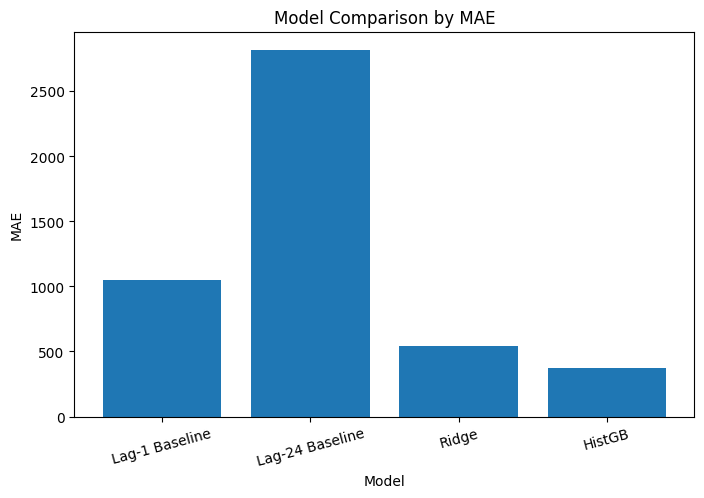

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.show()

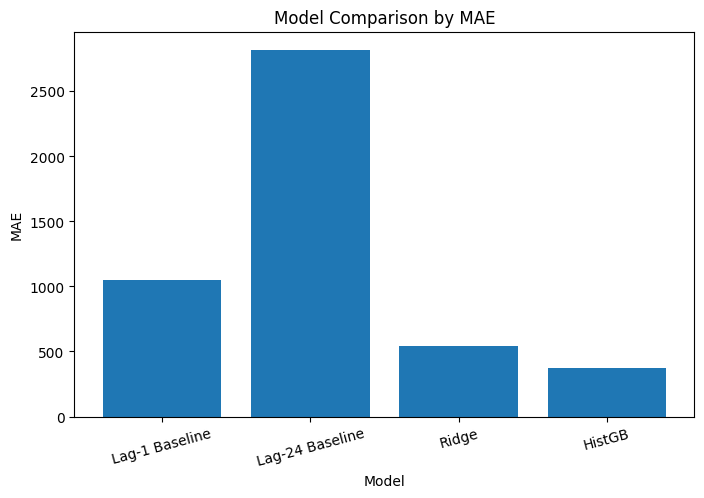

In [56]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.savefig("model_comparison_mae.png", bbox_inches="tight")
plt.show()

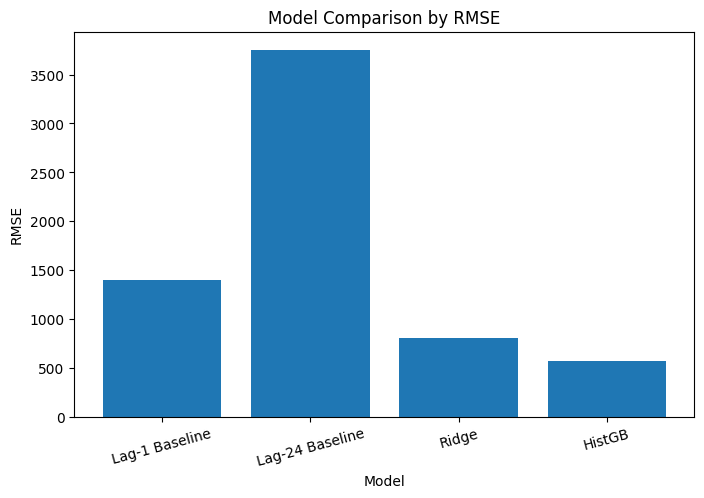

In [57]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

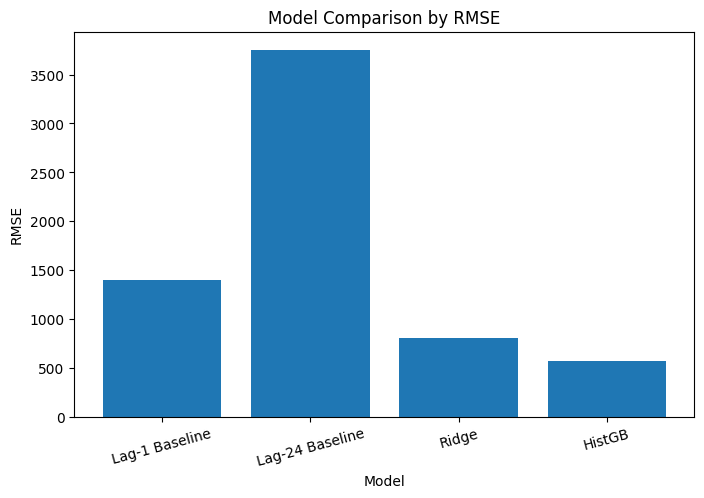

In [58]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.savefig("model_comparison_rmse.png", bbox_inches="tight")
plt.show()

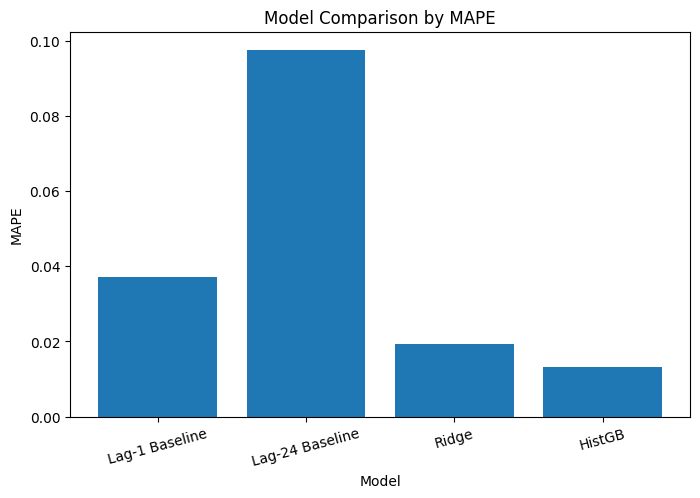

In [59]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAPE"])
plt.title("Model Comparison by MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE")
plt.xticks(rotation=15)
plt.show()

**Actual vs Predicted Load for HistGB**

In [60]:
comparison_df = pd.DataFrame({
    "time": time_test,
    "actual_load": y_test,
    "predicted_load_histgb": y_pred_histgb
}).reset_index(drop=True)

In [61]:
print(comparison_df.head())

                       time  actual_load  predicted_load_histgb
0 2018-03-16 08:00:00+00:00      34920.0           35037.593751
1 2018-03-16 09:00:00+00:00      34837.0           35003.075740
2 2018-03-16 10:00:00+00:00      34651.0           34670.488643
3 2018-03-16 11:00:00+00:00      34338.0           34145.824847
4 2018-03-16 12:00:00+00:00      33245.0           33230.179661


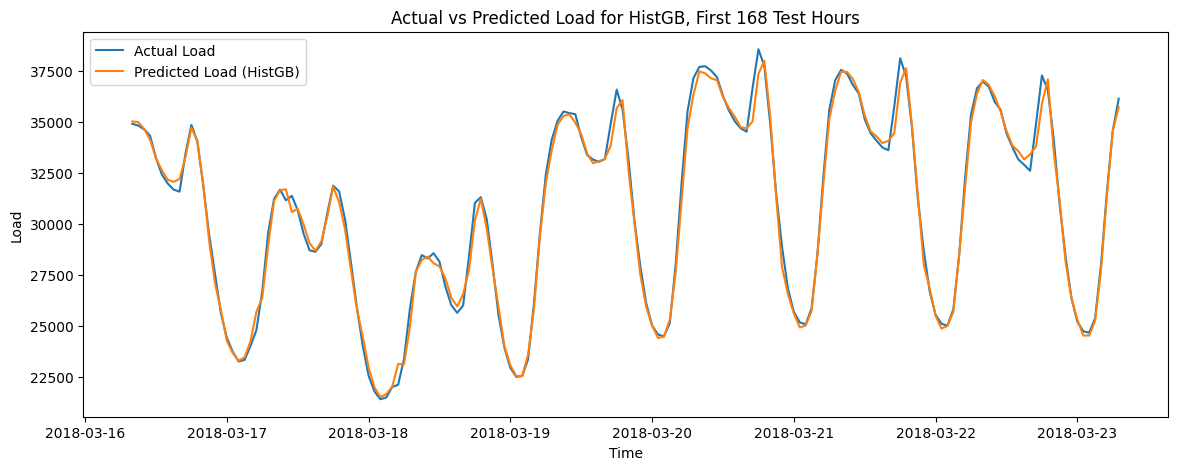

In [62]:
plt.figure(figsize=(14, 5))
plt.plot(comparison_df["time"].iloc[:168], comparison_df["actual_load"].iloc[:168], label="Actual Load")
plt.plot(comparison_df["time"].iloc[:168], comparison_df["predicted_load_histgb"].iloc[:168], label="Predicted Load (HistGB)")
plt.title("Actual vs Predicted Load for HistGB, First 168 Test Hours")
plt.xlabel("Time")
plt.ylabel("Load")
plt.legend()
plt.show()

In [63]:
comparison_df["error_histgb"] = comparison_df["actual_load"] - comparison_df["predicted_load_histgb"]

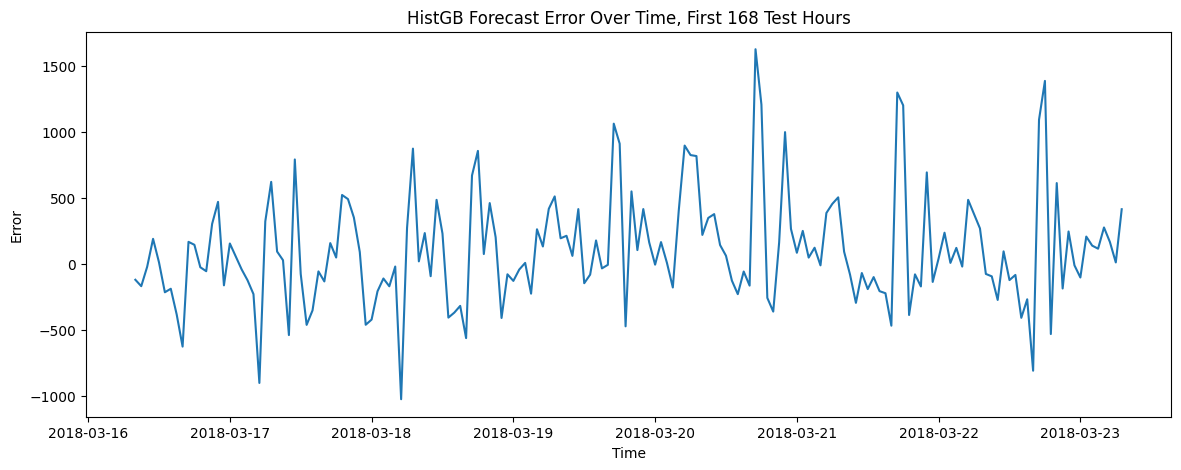

In [64]:
plt.figure(figsize=(14, 5))
plt.plot(comparison_df["time"].iloc[:168], comparison_df["error_histgb"].iloc[:168])
plt.title("HistGB Forecast Error Over Time, First 168 Test Hours")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

In [67]:
from google.colab import files
comparison_df.to_csv('capstone_forecasting.csv', index=False)
files.download("capstone_forecasting.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>